In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)


from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import joblib


In [2]:
df=pd.read_csv("C:/Users/jaine/OneDrive/Desktop/PROJECT/Data Science/Churn/Data/Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [42]:
df.shape

(7043, 20)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [8]:
df["TotalCharges"].dtype

dtype('float64')

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.columns=df.columns.str.capitalize()
df.columns=df.columns.str.replace(" ","_")

In [12]:
df = df.drop("Customerid", axis=1)

In [13]:
df["Churn"]=df["Churn"].map({"Yes":1,"No":0})

In [14]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [15]:
num_cols=X.select_dtypes(include=["Int64","float64"]).columns
num_cols

Index(['Seniorcitizen', 'Tenure', 'Monthlycharges', 'Totalcharges'], dtype='object')

In [16]:
cat_cols=X.select_dtypes(include=["object"]).columns
cat_cols

Index(['Gender', 'Partner', 'Dependents', 'Phoneservice', 'Multiplelines',
       'Internetservice', 'Onlinesecurity', 'Onlinebackup', 'Deviceprotection',
       'Techsupport', 'Streamingtv', 'Streamingmovies', 'Contract',
       'Paperlessbilling', 'Paymentmethod'],
      dtype='object')

In [17]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

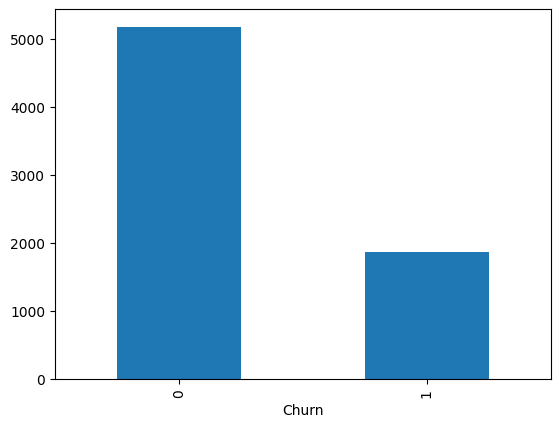

In [18]:
df["Churn"].value_counts().plot(kind="bar")
plt.show()

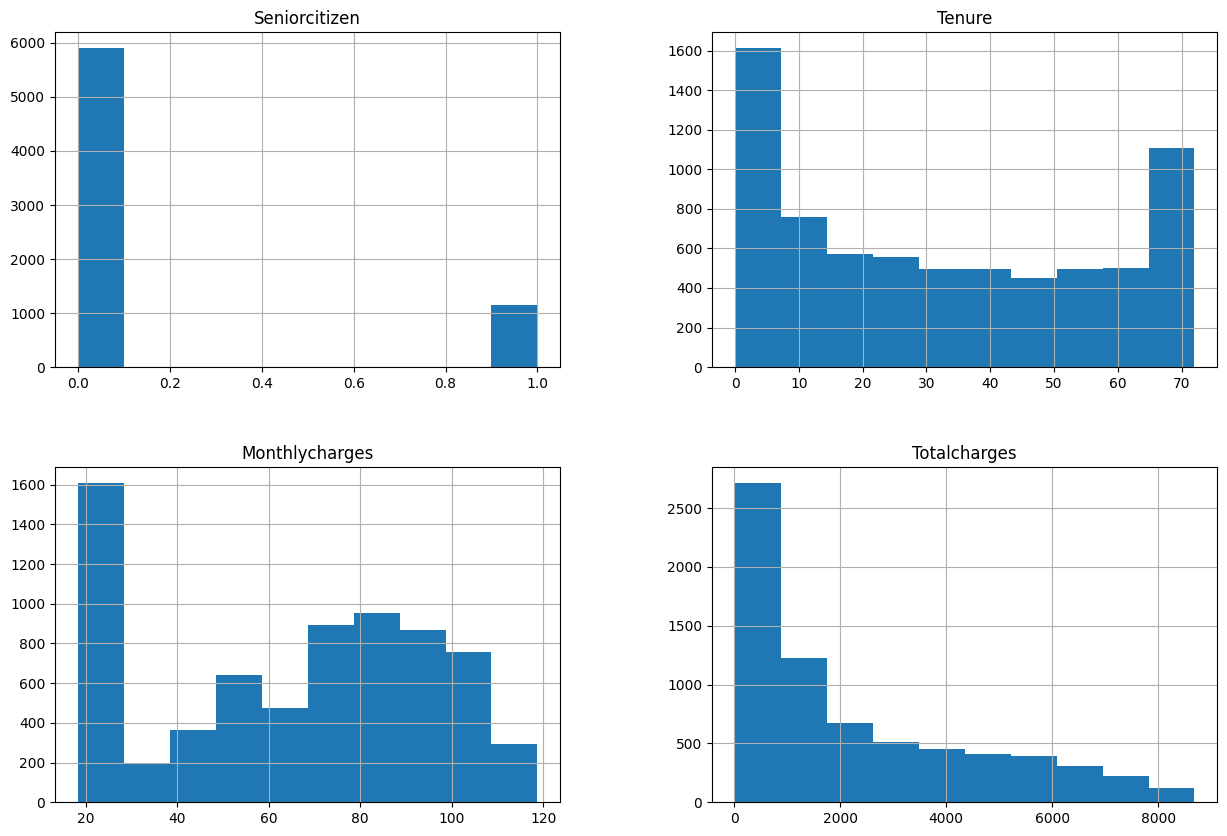

In [19]:
df[num_cols].hist(figsize=(15,10))
plt.show()

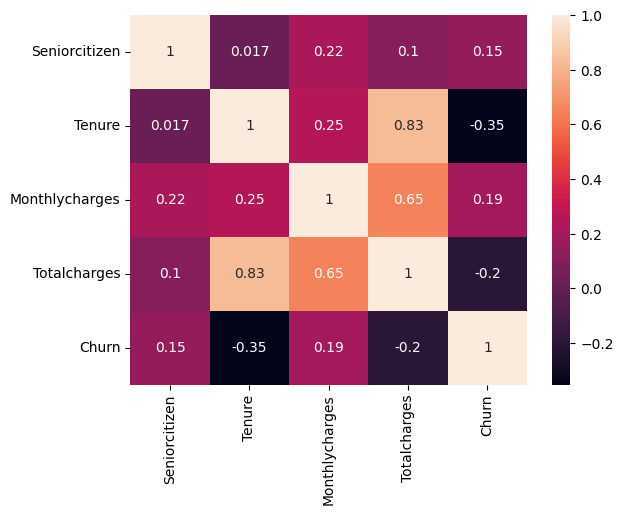

In [20]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [21]:
num_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="mean")),
    ("scaler",StandardScaler())
])

In [22]:
cat_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

In [23]:
preprocessor=ColumnTransformer([
    ("num",num_pipeline,num_cols),
    ("cat",cat_pipeline,cat_cols)
])

In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [25]:
print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [26]:
print(y_train.shape)
print(y_test.shape)

(5634,)
(1409,)


In [27]:
model_pipeline=Pipeline([
   ("preprocessing",preprocessor),
   ("model",CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=4,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=0,
        random_state=42
   ))
])

model_pipeline.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
y_pred=model_pipeline.predict(X_test)

y_prob=model_pipeline.predict_proba(X_test)[:,-1]



In [29]:
print("ROC-AUC Score:",roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.8451161228654835


In [30]:
print(accuracy_score(y_test,y_pred))

0.8119233498935415


In [31]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

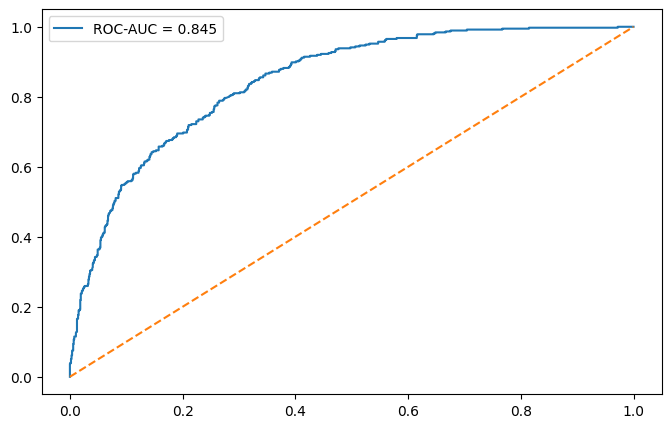

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc_score(y_test, y_prob):.3f}"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)
plt.legend()
plt.show()

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1035
           1       0.68      0.54      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [34]:
print(confusion_matrix(y_test,y_pred))

[[941  94]
 [171 203]]


In [35]:
y_pred_new=(y_prob>0.2).astype(int)

print(classification_report(y_test,y_pred_new))

              precision    recall  f1-score   support

           0       0.93      0.66      0.77      1035
           1       0.48      0.86      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.73      1409



In [36]:
confusion_matrix(y_test,y_pred_new) 

array([[686, 349],
       [ 54, 320]])

In [37]:
x_train_prob=model_pipeline.predict_proba(X_train)[:,-1]
x_test_prob=model_pipeline.predict_proba(X_test)[:,-1]

In [38]:
print(roc_auc_score(y_train,x_train_prob))
print(roc_auc_score(y_test,x_test_prob))

0.8839178028396176
0.8451161228654835


In [39]:
cv_scores = cross_val_score(
    estimator=model_pipeline,
    X=X,
    y=y,
    cv=5,
    scoring="roc_auc"
)

In [40]:
print(cv_scores)
print("Average ROC-AUC:",cv_scores.mean())

[0.8612997  0.85960758 0.83011832 0.84033881 0.8453206 ]
Average ROC-AUC: 0.8473370020271924


In [41]:
joblib.dump(model_pipeline,"C:/Users/jaine/OneDrive/Desktop/PROJECT/Data Science/Churn/Models/churn_model.pkl")

['C:/Users/jaine/OneDrive/Desktop/PROJECT/Data Science/Churn/Models/churn_model.pkl']